## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```


In [ ]:
your_name = 'Jonathan Cruz'
your_partner_name = ''

# **Road Accident Survival Dataset**
### Analyzing the Impact of Age, Speed, and Safety Measures on Accident Survival

* This dataset provides valuable insights into the factors that influence survival rates in road accidents. By analyzing variables such as age, speed, and safety measures, we can better understand patterns and identify critical factors affecting accident outcomes. This type of data analysis is crucial in real-world applications, such as improving road safety policies, designing better protective measures, and ultimately reducing fatalities. Through this exercise, you will apply machine learning techniques to gain meaningful insights, demonstrating the power of data analytics in addressing complex societal challenges.

* Get ready to uncover key relationships and enhance your understanding of predictive modeling!


In [1]:
#import libraries we will need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix

## **TASK 1:**

* Load the dataset

In [2]:
# Write your code here
df = pd.read_csv("accident.csv")

## **TASK 2: Basic Exploratory Data Analysis (EDA)**

* Implement at least four methods using Pandas to explore the data (i.e. apply some EDA).
  - What are the features and target variable in this dataset?
  - Are there any missing values? How would you handle them?
  - Plot the distribution of the target variable.

  Additionally, are there other things that would be useful to know about the dataset before doing any processing or modeling? What methods would provide useful and quick insights about the data?  Get creative!

In [3]:
# Write your code here

target = df.columns[-1]
features = df.columns[:-1]
print(f"Features: {features}")
print(f"Target: {target}")

Features: Index(['Age', 'Gender', 'Speed_of_Impact', 'Helmet_Used', 'Seatbelt_Used'], dtype='object')
Target: Survived


In [8]:
# Write your code here
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              200 non-null    int64  
 1   Gender           199 non-null    object 
 2   Speed_of_Impact  197 non-null    float64
 3   Helmet_Used      200 non-null    object 
 4   Seatbelt_Used    200 non-null    object 
 5   Survived         200 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 9.5+ KB


,Age,Speed_of_Impact,Survived
count,200.00000,197.000000,200.00000
mean,43.42500,70.441624,0.50500
std,14.94191,30.125298,0.50123
min,18.00000,20.000000,0.00000
25%,31.00000,43.000000,0.00000
50%,43.50000,71.000000,1.00000
75%,56.00000,95.000000,1.00000
max,69.00000,119.000000,1.00000


In [7]:
# Write your code here
print("\nMissing Values Per Col:")
print(df.isnull().sum())


Missing Values Per Col:
Age                0
Gender             1
Speed_of_Impact    3
Helmet_Used        0
Seatbelt_Used      0
Survived           0
dtype: int64



Target Distribution:
Survived
1    101
0     99
Name: count, dtype: int64


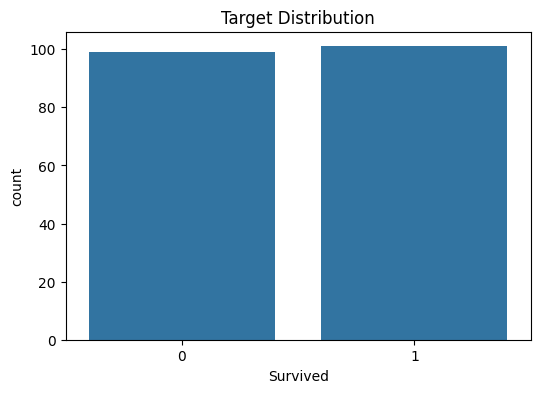

In [10]:
# Write your code here
print("\nTarget Distribution:")
print(df[target].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x=df[target])
plt.title("Target Distribution")
plt.show()

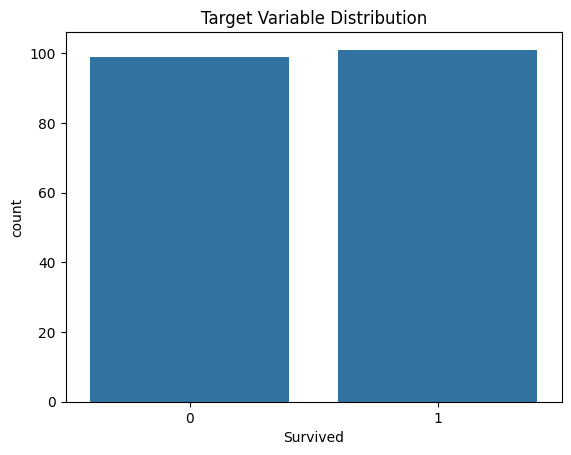

In [11]:
# Let's review the counts of each class records in our dataset to get a sense of
# its balance.
sns.countplot(x=target, data=df)
plt.title("Target Variable Distribution")
plt.show()

## **TASK 3: Preprocessing**

* Perform necessary data cleaning (i.e. drop missing values)
* encoding categorical variables & scaling preprocessing steps are provided for you since we will cover these next week during feature engineering
* Standardize the numerical features if necessary.

In [ ]:
# write your code here
df = df.dropna().copy()

target = df.columns[-1]
X = df.drop(columns=[target])
y = df[target]

num_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])



In [21]:
# Below is an example of encoding categorical variables and scaling numerical features in our dataset.
# We will learn more about why we need to do this for certain algorithms  when we cover feature engineering next week!
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Standardize numerical features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

## **TASK 4: Train-Test Split**

* Split the data into training and testing sets (80% train, 20% test).

In [22]:
# Write your code here
# ----- TASK 4: Train-Test Split -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y if y.nunique() <= 20 else None
)

## **TASK 5: Logistic Regression Implementation**

* Train a logistic regression model using the training data.
* Make predictions on the test set.


In [23]:
# Write your code here
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)


## **TASK 6: Question 5: Model Evaluation**

* While we haven't covered evaluation metrics for classification models yet, for this example, you only need to check for the accuracy of the model by using the `accuracy_score()` [method from scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html).
* Calculate the accuracy of the logistic regression model.
* Interpret the results with your partner. Is this a performative model?

In [24]:
# Write your code here
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4250


## **Review the Plots below**

* The classification report and confusion matrix visualizations below are provided for your observation. We will cover these metrics in detail in our lecture dedicated to Classification Evaluation later in the semester.

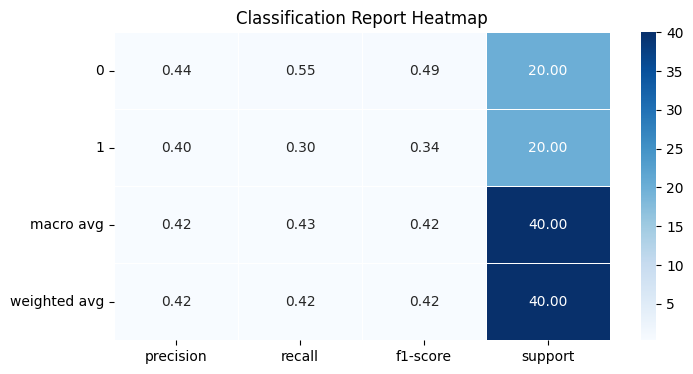

In [25]:
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' if you only want class-specific metrics
report_df = report_df.drop(["accuracy"], errors="ignore")

# Plot as a heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(report_df, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Classification Report Heatmap")
plt.show()


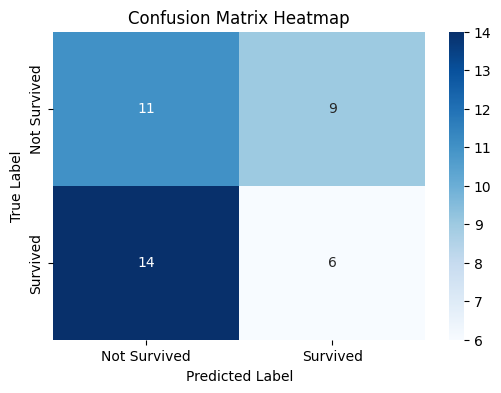

In [18]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Survived", "Survived"], yticklabels=["Not Survived", "Survived"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


In [19]:
# For your review. Let's look at the importance of features in the dataset
# Make sure you understand how this visualization is implemented and why it is useful.
coefficients = pd.Series(log_reg.coef_[0], index=features)
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

NameError: name 'log_reg' is not defined

## **TASK 6.1:**

* Interpret the plot above. This plot represents the feature importance in the logistic regression model, where each bar corresponds to a coefficient in the model.

## **Discuss with your partner and Write your answer to 6.1 here:**